In [ ]:
from src.run_app import *
from src.prepare_gam import *
from src.utils import *
from src.rset_opt import *
from FasterRisk.src.fasterrisk import fasterrisk
from gam_rs_utils.binarize_dataset import binarize_dataset
from gam_rs_utils.utils import *

import pandas as pd
from time import time

def plot_two_var_bar(results, x, y):
    fig, ax = plt.subplots()
    datasets = results["dataset"].unique()
    width = 0.8 / len(datasets)  # Adjust width for grouped bars
    x_vals = results[x].unique()
    x_indices = range(len(x_vals))
    
    for i, dataset_name in enumerate(datasets):
        data_group = results[results["dataset"] == dataset_name]
        ys = [data_group[data_group[x] == val][y].values[0] if not data_group[data_group[x] == val].empty else 0 for val in x_vals]
        offset = (i - len(datasets)/2) * width + width/2
        ax.bar([xi + offset for xi in x_indices], ys, width=width, label=dataset_name)

    ax.set_xticks(x_indices)
    ax.set_xticklabels(x_vals, rotation=45, ha='right')  # angled labels
    ax.set_xticklabels(x_vals)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.legend()
    plt.show()

dataset_settings = {
    'bank': {
        "l0": 0.001,
        "l2": 0.001,
        "m": 1.01,
        "r_min": 1,
        "merge_bins": 19,
    },
    'compas': {
        "l0": 0.001,
        "l2": 0.001,
        "m": 1.01,
        "r_min": 0.1,
        "merge_bins": 11,
    },
    "diabetes": {
        "l0": 0.001,
        "l2": 0.001,
        "m": 1.01,
        "r_min": 0.1,
        "merge_bins": 34,
    },
    # 'netherlands': {
    #     "l0": 0.001,
    #     "l2": 0.5,
    #     "m": 0.01,
    # },
    'spambase': {
        "l0": 0.001,
        "l2": 0.001,
        "m": 1.01,
        "r_min": 0.1,
        "merge_bins": 48,
    },
    'mimic2': {
        "l0": 0.0005,
        "l2": 0.001,
        "m": 1.01,
        "r_min": 0.1,
        "merge_bins": 35,
    }
}


### Swapping Method

In [ ]:
dataset_settings = {
    'bank': {
        'gap_tolerance': 0.006,
        'num_estimators': 50,
    },
    'compas': {
        'gap_tolerance': 0.0025,
        'num_estimators': 50,
    },
    'diabetes': {
        'gap_tolerance': 0.005,
        'num_estimators': 200,
    },
    'netherlands': {
        'gap_tolerance': 0.0015,
        'num_estimators': 50,
    },
    'spambase': {
        'gap_tolerance': 0.01,
        'num_estimators': 50,
    },
    'mimic2': {
        'gap_tolerance':0.002,
        'num_estimators': 50,
    },
}

results = []
for dataset_name, settings in dataset_settings.items():
    ne = settings["num_estimators"]
    gt = settings['gap_tolerance']

    path = 'datasets/{}.csv'.format(dataset_name)
    dataset = pd.read_csv(path)
    print(f"Dataset: {dataset_name}")
    print(f"Binarized shape: {dataset.shape}")

    df, thresholds, header, threshold_guess_time = binarize_dataset(dataset, ne)
    X, y = df.iloc[:, :-1], df.iloc[:, -1]
    header = pd.Index(["intercept"] + list(X.columns)).astype("object")
    X_one_hot, y = utils.get_X_y(X, y)

    start = time()
    rs = fasterrisk.RiskScoreOptimizer(X_one_hot, y, k=15, lb=-100, ub=100, gap_tolerance=gt, select_top_m=-1, maxAttempts=25)
    rs.optimize_with_swaps_beam_search(swaps=5, beam_size=100, verbose=True)
    end = time()

    print(f"\t{rs.sparseDiversePool_betas.shape[0]} solutions, {end - start:.2f} seconds")
    results.append({
        "dataset": dataset_name,
        "dataset_shape": dataset.shape,
        "num_estimators": ne,
        "gap_tolerance": gt,
        "threshold_guess_time": threshold_guess_time,
        "num_features": len(header),
        "runtime": end - start,
        "betas": rs.sparseDiversePool_betas,
        "beta0": rs.sparseDiversePool_beta0,
        "num_solutions": rs.sparseDiversePool_betas.shape[0],
        "loss": get_loss(X_one_hot, y, rs.sparseDiversePool_beta0, rs.sparseDiversePool_betas),
        "predictions": get_predictions(X_one_hot, rs.sparseDiversePool_beta0, rs.sparseDiversePool_betas),
    })

with open(f"analysis/results/swapping_method.pkl", "wb") as f:
    pickle.dump(results, f)

Dataset: bank
Binarized shape: (4521, 17)
swap 0, beam size 1
swap 1, beam size 49
swap 2, beam size 100
swap 3, beam size 100
swap 4, beam size 100
	100 solutions, 356.23 seconds
Dataset: compas
Binarized shape: (6907, 8)
swap 0, beam size 1
swap 1, beam size 58
swap 2, beam size 100
swap 3, beam size 100
swap 4, beam size 100
	100 solutions, 296.97 seconds
Dataset: diabetes
Binarized shape: (768, 9)
swap 0, beam size 1
swap 1, beam size 15
swap 2, beam size 47
swap 3, beam size 44
swap 4, beam size 55
	100 solutions, 13.45 seconds
Dataset: netherlands
Binarized shape: (20000, 10)
swap 0, beam size 1
swap 1, beam size 56
swap 2, beam size 100
swap 3, beam size 100
swap 4, beam size 100
	100 solutions, 1206.28 seconds
Dataset: spambase
Binarized shape: (4601, 58)
swap 0, beam size 1
swap 1, beam size 14
swap 2, beam size 65
swap 3, beam size 100
swap 4, beam size 100
	37 solutions, 84.42 seconds
Dataset: mimic2
Binarized shape: (24508, 18)
swap 0, beam size 1
swap 1, beam size 16
swap 

### Ellipsoid Sampling

In [ ]:
methods = [
    {"method": "uniform"},
    {"method": "poisson", "max_attempts": 1000},
]

for method in methods:
    results = []
    for dname, settings in dataset_settings.items():
        l0 = settings["l0"]
        l2 = settings["l2"]
        m = settings["m"]
        filepath = "{}_{}_{}_{}.p".format(dname, l0, l2, m)

        betas_fastSparse = prepare_sparse_gam(dname, lamb0=l0, lamb2=l2, multiplier=m)

        if method["method"] == "poisson":
            method["r_min"] = settings["r_min"]
        w_samples = get_models_from_rset(filepath, n_samples=100, plot_shape=False, sample_from_surface=False, method=method)
        X = pickle.load(open(betas_fastSparse, 'rb'))['X']
        data = pd.read_csv("datasets/{}.csv".format(dname))
        y = data.iloc[:, -1].values
        y_max, y_min = np.max(y), np.min(y)
        y = -1 + 2 * (y-y_min)/(y_max-y_min)

        print("Loss: ", get_loss(X, y, np.zeros(w_samples.shape[0]), w_samples))

        results.append({
            "dataset": dname,
            "l0": l0,
            "l2": l2,
            "m": m,
            "w_samples": w_samples,
            "predictions": get_predictions(X, np.zeros(len(w_samples)), w_samples),
        })

    with open(f"""analysis/results/{method["method"]}_method.pkl""", "wb") as f:
        pickle.dump(results, f)

### Blocking Method

In [16]:
from blocking_method.blocking import optimize_support

for dname, settings in dataset_settings.items():
    l0 = settings["l0"]
    l2 = settings["l2"]
    m = settings["m"]
    merge_bins = settings["merge_bins"]

    filepath = "{}_{}_{}_{}.p".format(dname, l0, l2, m)
    # opt = RSetOPT(filepath)
    # support = opt.P
    print(filepath, merge_bins)
    optimize_support(filepath, merge_bins, 100)

bank_0.001_0.001_1.01.p 21
0.6054 0.246791934289253
sample_p [1.         0.43397478 0.56602522 0.84715771 0.15284229 0.70714444
 0.29285556 0.97080292 0.02919708 0.56359213 0.20880336 0.1481973
 0.03163017 0.04777704 0.99270073 0.00729927 0.81950896 0.06326034
 0.1172307  0.15195753 0.84804247]
delta_support = 2, new rsetbound = 0.248791934289253, delta rsetbound = 0.002
----------- before optimization -----------
volume proportional to  tensor(3.5345e+24, dtype=torch.float64, grad_fn=<MulBackward0>)
0 tensor(0.0678, dtype=torch.float64, grad_fn=<AddBackward0>)
1 tensor(0.0676, dtype=torch.float64, grad_fn=<AddBackward0>)
2 tensor(0.0675, dtype=torch.float64, grad_fn=<AddBackward0>)
3 tensor(0.0674, dtype=torch.float64, grad_fn=<AddBackward0>)
4 tensor(0.0675, dtype=torch.float64, grad_fn=<AddBackward0>)
5 tensor(0.0671, dtype=torch.float64, grad_fn=<AddBackward0>)
6 tensor(0.0670, dtype=torch.float64, grad_fn=<AddBackward0>)
7 tensor(0.0669, dtype=torch.float64, grad_fn=<AddBackward0>

In [33]:
def get_new_X(indices, X):
    new_X = []
    col_pointer = 0
    for i, j in indices:
        if i > col_pointer:
            new_X.append(X[:, col_pointer:i])
        merged = np.max(X[:, i:j+1], axis=1, keepdims=True)
        new_X.append(merged)
        col_pointer = j + 1
    if col_pointer < X.shape[1]:
        new_X.append(X[:, col_pointer:])
    new_X = np.hstack(new_X)
    return new_X

In [ ]:
results = []
for dname, settings in dataset_settings.items():
    l0 = settings["l0"]
    l2 = settings["l2"]
    m = settings["m"]
    merge_bins = settings["merge_bins"]
    
    with open(f"{dname}_{l0}_{l2}_{m}_merge_bins_{merge_bins}.p", "rb") as f:
        out = pickle.load(f)
    with open(f"{dname}_{l0}_{l2}_{m}.p", "rb") as f:
        res = pickle.load(f)

    predictions = np.zeros((res["X"].shape[0], len(out["indices"])))
    for support in range(len(out["indices"])):
        new_X = get_new_X(out["indices"][support], res["X"])
        w_sample = out["w_center_block"][support]

        logit = new_X @ w_sample
        y_pred = np.exp(logit) / (1 + np.exp(logit))
        y_pred = np.where(y_pred > 0.5, 1, -1)
        predictions[:, support] = y_pred

    results.append({
        "dataset": dname,
        "w_samples": w_samples,
        "predictions": predictions,
    })

with open(f"""analysis/results/blocking_method.pkl""", "wb") as f:
    pickle.dump(results, f)

### Ellipsoid Zeroing

### Comparison

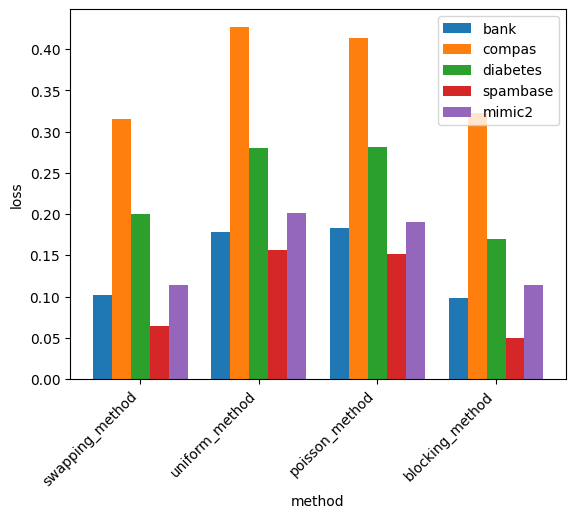

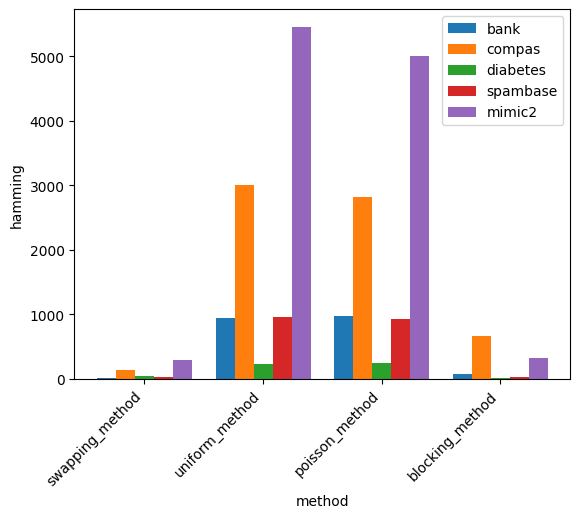

In [48]:
methods = ["swapping_method", "uniform_method", "poisson_method", "blocking_method"]
dataset_names = ["bank", "compas", "diabetes", "spambase", "mimic2"]


dname_list, method_list, losses, hamming = [], [], [], []
for dname in dataset_names:
    for method in methods:
        with open(f"analysis/results/{method}.pkl", "rb") as f:
            results = pickle.load(f)
        df = pd.DataFrame(results)
        df = df[df["dataset"] == dname]

        for i, row in df.iterrows():
            predictions = row["predictions"]

            dataset = pd.read_csv(f"datasets/{dname}.csv")
            df, _, _, _ = binarize_dataset(dataset, 50)
            X, y = df.iloc[:, :-1], df.iloc[:, -1]
            X_one_hot, y = utils.get_X_y(X, y)
            y_broadcasted = np.repeat(y[:, np.newaxis], predictions.shape[1], axis=1)

            loss_matrix = (predictions != y_broadcasted)
            dname_list.append(dname)
            method_list.append(method)
            losses.append(loss_matrix.mean())
            hamming.append(average_pairwise_diversity(predictions.T, hamming_distance, limit=100))

results_df = pd.DataFrame({
    "dataset": dname_list,
    "method": method_list,
    "loss": losses,
    "hamming": hamming
})

plot_two_var_bar(results_df, "method", "loss")
plot_two_var_bar(results_df, "method", "hamming")

In [ ]:
method = "poisson method"
with open(f"analysis/results/{method}.pkl", "rb") as f:
    results = pickle.load(f)
    df = pd.DataFrame(results)
    df = df[df["dataset"] == dname]